# Computational Carpentry Project

Team members :
- Gregorio Adriano Rolli 
- Bogdan Filipchuk
- Yunhee Choi
- Artem Hrynov

## Part A — Data structures and functions

### 1. Load the periodic table


In [1]:
import pandas as pd

periodic_table = pd.read_csv("periodic_table.csv")
periodic_table.head()


,AtomicNumber,Symbol,Name,AtomicMass,CPKHexColor,ElectronConfiguration,Electronegativity,AtomicRadius,IonizationEnergy,ElectronAffinity,OxidationStates,StandardState,MeltingPoint,BoilingPoint,Density,GroupBlock,YearDiscovered
0,1,H,Hydrogen,1.008000,FFFFFF,1s1,2.20,120.0,13.598,0.754,"+1, -1",Gas,13.81,20.28,0.000090,Nonmetal,1766
1,2,He,Helium,4.002600,D9FFFF,1s2,NaN,140.0,24.587,NaN,0,Gas,0.95,4.22,0.000179,Noble gas,1868
2,3,Li,Lithium,7.000000,CC80FF,[He]2s1,0.98,182.0,5.392,0.618,+1,Solid,453.65,1615.00,0.534000,Alkali metal,1817
3,4,Be,Beryllium,9.012183,C2FF00,[He]2s2,1.57,153.0,9.323,NaN,+2,Solid,1560.00,2744.00,1.850000,Alkaline earth metal,1798
4,5,B,Boron,10.810000,FFB5B5,[He]2s2 2p1,2.04,192.0,8.298,0.277,+3,Solid,2348.00,4273.00,2.370000,Metalloid,1808


### 2. Dictionary

`.set_index()` replaces integer indexes by the `Symbol`. The key `"Symbol"` associates each symbol with its value `"AtomicMass"`; `to_dict()` converts that mapping into a Python dictionary.


In [2]:
atomic_masses = periodic_table.set_index("Symbol")["AtomicMass"].to_dict()

atomic_masses


{'H': 1.008,
 'He': 4.0026,
 'Li': 7.0,
 'Be': 9.012183,
 'B': 10.81,
 'C': 12.011,
 'N': 14.007,
 'O': 15.999,
 'F': 18.99840316,
 'Ne': 20.18,
 'Na': 22.9897693,
 'Mg': 24.305,
 'Al': 26.981538,
 'Si': 28.085,
 'P': 30.973762,
 'S': 32.07,
 'Cl': 35.45,
 'Ar': 39.9,
 'K': 39.0983,
 'Ca': 40.08,
 'Sc': 44.95591,
 'Ti': 47.867,
 'V': 50.9415,
 'Cr': 51.996,
 'Mn': 54.93804,
 'Fe': 55.84,
 'Co': 58.93319,
 'Ni': 58.693,
 'Cu': 63.55,
 'Zn': 65.4,
 'Ga': 69.723,
 'Ge': 72.63,
 'As': 74.92159,
 'Se': 78.97,
 'Br': 79.9,
 'Kr': 83.8,
 'Rb': 85.468,
 'Sr': 87.62,
 'Y': 88.90584,
 'Zr': 91.22,
 'Nb': 92.90637,
 'Mo': 95.95,
 'Tc': 96.90636,
 'Ru': 101.1,
 'Rh': 102.9055,
 'Pd': 106.42,
 'Ag': 107.868,
 'Cd': 112.41,
 'In': 114.818,
 'Sn': 118.71,
 'Sb': 121.76,
 'Te': 127.6,
 'I': 126.9045,
 'Xe': 131.29,
 'Cs': 132.905452,
 'Ba': 137.33,
 'La': 138.9055,
 'Ce': 140.116,
 'Pr': 140.90766,
 'Nd': 144.24,
 'Pm': 144.91276,
 'Sm': 150.4,
 'Eu': 151.964,
 'Gd': 157.2,
 'Tb': 158.92535,
 'Dy': 16

### 3. Molecular mass formula

Read the formula from left to right. Each element symbol begins with an uppercase letter and can include a lowercase letter. The digits following it give the number of atoms. Without digits, the count is 1. Multiply each count by the atomic mass from `atomic_masses` and add the contributions. Using `while` loops instead of `for in` give more control over each step.


In [3]:
def molecular_mass(chemical_formula: str) -> float:
    """Returns the molecular mass of a chemical based on its formula"""

    total_mass = 0.0
    i = 0

    while i < len(chemical_formula):
        if chemical_formula[i] not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ": #reads the symbol, uppecase then lowercase
            raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.") #the first letter is always uppercase ; i + 1 makes it more human readable
        symbol = chemical_formula[i]
        i += 1
        if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz": #lowercase if two-letter symbol
            symbol += chemical_formula[i] #now symbol contains the str of one atom
            i += 1

        if symbol not in atomic_masses:
            raise ValueError(f"Unknown element: {symbol}")

        count_start = i #initiates the count of the digits, to handle pluridigit counts
        while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
            i += 1
        count_text = chemical_formula[count_start:i] #extracts the number as a str
        count = int(count_text) if count_text else 1 #converts to int

        total_mass += atomic_masses[symbol] * count #adds the mass of one passage of the loop (i.e. one atomic symbol times its number)

    return total_mass


In [4]:
#examples
for formula in ["H2O", "C6H12O6", "NaCl"]:
    print(f"{formula}: {molecular_mass(formula)}")


H2O: 18.015
C6H12O6: 180.156
NaCl: 58.4397693


### 4. Handle parentheses using recursion

When `parse_group` encounters `(`, it calls itself to calculate the mass inside the parentheses. That call returns at the matching `)`, then we multiply the group mass by the following count.

Each call returns both its mass and the next unread position, so the outer call knows where to continue.


In [5]:
def molecular_mass(chemical_formula: str)-> float:
    """Returns the molecular mass of a chemical based on its formula, including groups in parentheses."""

    def read_count(i) -> tuple[int, int]: #does the same thing as point 3 but inside a function for either a group or a symbol
        """Read an optional positive integer and return the next position."""
        start = i
        while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
            i += 1
        count = int(chemical_formula[start:i]) if i > start else 1
        return count, i

    def parse_group(i) -> tuple[float, int]:
        total_mass = 0.0

        while i < len(chemical_formula):
            character = chemical_formula[i]

            if character == ")":
                return total_mass, i + 1 #i + 1 makes it continue after the parenthesis

            if character == "(":
                term_mass, i = parse_group(i + 1) #recursively calls the parse_group function
            else:
                if character not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
                    raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.")
                symbol = character
                i += 1
                if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz":
                    symbol += chemical_formula[i]
                    i += 1
                if symbol not in atomic_masses:
                    raise ValueError(f"Unknown element: {symbol}")
                term_mass = atomic_masses[symbol]

            count, i = read_count(i)
            total_mass += term_mass * count

        return total_mass, i

    total_mass= parse_group(0)[0] #selects only the mass from the tuple
    return total_mass


In [6]:
#examples
for formula in ["Ca(OH)2", "Al2(SO4)3", "(NH4)2SO4", "K4(ON(SO3)2)2"]:
    print(f"{formula}: {molecular_mass(formula)} u")


Ca(OH)2: 74.094 u
Al2(SO4)3: 342.161076 u
(NH4)2SO4: 132.144 u
K4(ON(SO3)2)2: 536.6732000000001 u


### 5. Handle hydration water

Split the formula at each dot (`.`). A leading number multiplies the entire component after it.


In [7]:
def molecular_mass(chemical_formula: str) -> float:
    """Return molecular mass in u, including parentheses and hydration water."""

    #reused the point 4 algorithm to calculate each components mass
    def component_mass(chemical_formula: str) -> float:
        """Return molecular mass in u, including groups in parentheses."""

        def read_count(i) -> tuple[int, int]: #does the same thing as point 3 but inside a function for either a group or a symbol
            """Read an optional positive integer and return the next position."""
            start = i
            while i < len(chemical_formula) and chemical_formula[i] in "0123456789":
                i += 1
            count = int(chemical_formula[start:i]) if i > start else 1
            return count, i

        def parse_group(i) -> tuple[float, int]:
            total_mass = 0.0

            while i < len(chemical_formula):
                character = chemical_formula[i]

                if character == ")":
                    return total_mass, i + 1 #i + 1 makes it continue after the parenthesis

                if character == "(":
                    term_mass, i = parse_group(i + 1) #recursively calls the parse_group function
                else:
                    if character not in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
                        raise ValueError(f"Expected an uppercase element symbol at position {i + 1}.")
                    symbol = character
                    i += 1
                    if i < len(chemical_formula) and chemical_formula[i] in "abcdefghijklmnopqrstuvwxyz":
                        symbol += chemical_formula[i]
                        i += 1
                    if symbol not in atomic_masses:
                        raise ValueError(f"Unknown element: {symbol}")
                    term_mass = atomic_masses[symbol]

                count, i = read_count(i)
                total_mass += term_mass * count

            return total_mass, i

        total_mass= parse_group(0)[0] #selects only the mass from the tuple
        return total_mass        

    total_mass = 0.0
    components = chemical_formula.split(".") #each component separated by a "." is added to a list of str
    for component in components:
        i = 0
        while i < len(component) and component[i] in "0123456789": #assures pluridigit coefficients are properly counted
            i += 1
        coefficient = int(component[:i]) if i else 1 #extracts the coefficient form the component
        formula = component[i:] #extracts the formula from the component

        total_mass += coefficient * component_mass(formula)

    return total_mass


In [8]:
#examples
for formula in ["CuSO4.5H2O", "Na2CO3.10H2O", "Al2(SO4)3.18H2O"]:
    print(f"{formula}: {molecular_mass(formula)} u")


CuSO4.5H2O: 249.69100000000003 u
Na2CO3.10H2O: 286.13753859999997 u
Al2(SO4)3.18H2O: 666.431076 u


## Part B - Stoichiometry and reaction balancing (30 points)

1. **Reaction Balancer Function (20 points)**
   - Write a function `balance_reaction(reactants, products)` that:
     - Takes as input:
       - `reactants`: list of chemical formulas for reactants (e.g., `["H2", "O2"]`)
       - `products`: list of chemical formulas for products (e.g., `["H2O"]`)
     - Returns: a **list of stoichiometric coefficients** that balances the reaction.
     - You don't need to consider parenthesis or "." in the formula for this problem.
     - **Hint:** You can represent the reaction as a system of linear equations based on the number of atoms of each element. Look up the term Singular Value Decomposition, you can use [this](https://en.wikipedia.org/wiki/Singular_value_decomposition) link.
     - Test it for 3 reactions of your choice.


In [9]:
import numpy as np
from fractions import Fraction
from math import gcd


def parse_elements(compoundlist:list[str])->set[str]:
    """
    Returns a set of elements present in the current list of atoms 
    """
    elements = set()
    for reactant in compoundlist:
            for index, character in enumerate(reactant):
                if character.isupper():
                    element = character
                    if index+1 < len(reactant) and reactant[index+1].islower():  ### To account for two symbol elements
                        element+=reactant[index+1]
                    elements.add(element)
    return elements

def read_number(atom:str, index:int) -> tuple[int,int]:
    """
    Reads the digits starting at index untill the next non-digit. Returns (number, index just after them), no digits meaning 1.
    """
    digits = ""
    while index < len(atom) and atom[index].isdigit():
        digits += atom[index]
        index += 1
    return int(digits) if digits else 1, index


## This code (no ai) works if we don't account for nesting like brackets or parantheses. 
def numberofatoms_no_nesting(atom:str) -> dict[str,int]:
    """
    Returns a dict with atoms as keys and number of times this atom occurs in the molecule as value
    """
    mydict:dict[str,int]= {}
    elements = parse_elements([atom])
    for element in elements:
        counter:int = 0
        for index, character in enumerate(atom):

            if atom[index:index+len(element)] == element:

                digit_index = index + len(element)                                                                                          # start looking for numbers right after the element's letters
                if len(element) == 1 and digit_index < len(atom) and atom[digit_index].islower():                                           #prevents 1 character elements misfiring when they share the same letter with a 2 letter element like Cl (good thing i noticed that, tough stuff)
                    continue
                digits = ""                                                                                                                 #Starts collecting digits into a string, needs to be converted to int later ?
                while digit_index < len(atom) and atom[digit_index].isdigit():
                    digits += atom[digit_index]                                                                                             # keep grabbing characters as long as they're digits
                    digit_index += 1

                counter += int(digits) if digits else 1                                                                                     # no digits found = implicit count of 1

        mydict[element] = counter
    return mydict

### This code DOES account for nesting, but uses a stack structure proposed by AI. It works great but the asignment said we can ommit paranthesis.
def numberofatoms_with_nesting(atom:str) -> dict[str,int]:
    """
    Returns a dict with atoms as keys and number of times this atom occurs in the molecule as value.
    Parentheses and brackets are handled by keeping one dict per nesting level on a stack: opening a
    group pushes a fresh dict, closing it pops that dict and merges it into the level below, each
    count multiplied by the group's subscript.
    """
    stack:list[dict[str,int]] = [{}]
    index:int = 0

    while index < len(atom):
        character = atom[index]

        if character == "(" or character == "[":
            stack.append({})
            index += 1

        elif character == ")" or character == "]":
            group = stack.pop()
            multiplier, index = read_number(atom, index + 1)                              #Multiplies the 
            for element, count in group.items():
                stack[-1][element] = stack[-1].get(element, 0) + count * multiplier

        elif character.isupper():
            element = character
            index += 1
            if index < len(atom) and atom[index].islower():                 ### To account for two symbol elements
                element += atom[index]
                index += 1
            count, index = read_number(atom, index)
            stack[-1][element] = stack[-1].get(element, 0) + count

        else:
            index += 1                                                      # anything else just gets skipped

    return stack[0]


def balance_reaction(reactants:list[str], products:list[str])->list[str]:  
    """Takes in reactants and products as a list of strings and returns a list of stoechiometric coefficients corresponding to them"""
    numberofatoms = numberofatoms_with_nesting if nesting else numberofatoms_no_nesting
    ###Staging the matrix                                                                                                            
    elements = list[str](parse_elements(reactants) | parse_elements(products))                                                          #Converting the elemets set to list since we will iterate over them later 
    rows:int = len(elements)                                                                                                            #will represent elements in the matrix
    columns:int = len(reactants)+len(products)                                                                                          #represent stoechiometric coefficients in the matrix
    my_matrix = np.zeros((rows,columns))
    compounds = reactants + products

    ###Forming the matrix to solve
    for row in range(rows):
        for column in range(columns):
            if column<len(reactants):
                my_matrix[row, column] = numberofatoms(compounds[column]).get(elements[row], 0)
            else:
                my_matrix[row, column] = -numberofatoms(compounds[column]).get(elements[row], 0)
    stoechiometric_coefficients:list[int] = solve_matrix(my_matrix)

    ###Debug, displays nicely how the matrix to solve with SVD was formed
    if debug:
        
        print("Rows and columns represent:\n", "   ",*reactants,"->", *products)
        print(*elements, sep="\n")
        print(my_matrix)

    return stoechiometric_coefficients


def solve_matrix(matrix:np.ndarray) -> list[int]:
    """
    Takes the m x n matrix built by balance_reaction and returns the smallest vector of
    whole numbers x such that matrix @ x = 0.

    The columns of V (from the SVD matrix = U @ S @ V.T) that pair with a zero singular
    value span the null space, so the last one of them is a valid solution. It comes out
    as floats, so it gets rescaled into the smallest equivalent integers.
    """
    U, singular_values, Vt = np.linalg.svd(matrix)

    tolerance = max(matrix.shape) * np.finfo(float).eps * singular_values[0]                     # a singular value is never exactly 0 in floating point
    rank:int = int(np.sum(singular_values > tolerance))
    if rank == matrix.shape[1]:
        raise ValueError("Only the trivial all-zero solution exists, the reaction cannot be balanced")

    solution = Vt[-1]                                                                            # last row of V.T = last column of V = a null space vector

    ###Turning the floats into the smallest possible whole numbers
    solution = solution / np.min(np.abs(solution[np.abs(solution) > 1e-10]))                     # smallest non zero entry becomes 1
    fractions = [Fraction(value).limit_denominator(1000) for value in solution]
    common_denominator:int = 1
    for fraction in fractions:
        common_denominator = common_denominator * fraction.denominator // gcd(common_denominator, fraction.denominator)

    return [int(fraction * common_denominator) for fraction in fractions]


### Tests
debug = False
nesting = True          # numberofatoms_with_nesting is the correct parser and costs nothing on simple
                        # formulas. With nesting = False, "[Cr(N2H4CO)6]4[Cr(CN)6]3" is read as
                        # Cr2 N3 H4 C2 O1 instead of Cr7 N66 H96 C42 O24, and balance_reaction then
                        # returns clean-looking but wrong coefficients without raising anything.

### The brief asks for three test reactions; the fourth is the nesting case above.
test_reactions: list[tuple[list[str], list[str]]] = [
    (["H2", "O2"], ["H2O"]),                                        # 2 H2 + O2 -> 2 H2O
    (["C6H12O6", "O2"], ["CO2", "H2O"]),                            # combustion of glucose
    (["KMnO4", "HCl"], ["KCl", "MnCl2", "H2O", "Cl2"]),             # redox, 6 unknowns
    (["[Cr(N2H4CO)6]4[Cr(CN)6]3", "KMnO4", "H2SO4"],                # nested brackets, 9 unknowns
     ["K2Cr2O7", "MnSO4", "CO2", "KNO3", "K2SO4", "H2O"]),
]

for reactants, products in test_reactions:
    coefficients = balance_reaction(reactants, products)
    left = " + ".join(f"{c} {f}" for c, f in zip(coefficients, reactants))
    right = " + ".join(f"{c} {f}" for c, f in zip(coefficients[len(reactants):], products))
    print(f"{left}  ->  {right}")

2 H2 + 1 O2  ->  2 H2O
1 C6H12O6 + 6 O2  ->  6 CO2 + 6 H2O
2 KMnO4 + 16 HCl  ->  2 KCl + 2 MnCl2 + 8 H2O + 5 Cl2
10 [Cr(N2H4CO)6]4[Cr(CN)6]3 + 1176 KMnO4 + 1399 H2SO4  ->  35 K2Cr2O7 + 1176 MnSO4 + 420 CO2 + 660 KNO3 + 223 K2SO4 + 1879 H2O


2. **Mass Conservation Check (10 points)**
   - Using the molecular mass calculator from **Part A**, compute the total mass of reactants and products with the coefficients found. Achieve this by writing a function which takes a dictionary of molecules and their coefficient and return a True or False.
   - Verify that the total mass is conserved. Print a message indicating whether the reaction is balanced.


In [10]:
from math import isclose


def mass_conservation_check(substrate_dictionary:dict[str,float], product_dictionary:dict[str,float],
                            relative_tolerance:float=1e-9)->bool:
    """
    Returns True when the reactant side and the product side have the same total mass.

    The two sums add the same atoms in a different order, so in floating point they can differ
    by ~1e-13 u even for a perfectly balanced reaction. That is why they are compared with
    math.isclose and not with ==.
    """
    substrate_mass_sum:float = 0.0
    product_mass_sum:float = 0.0
    for substrate in substrate_dictionary.keys():
        substrate_mass_sum+=substrate_dictionary.get(substrate)*molecular_mass(substrate)
    for product in product_dictionary.keys():
        product_mass_sum+=product_dictionary.get(product)*molecular_mass(product)

    balanced:bool = isclose(substrate_mass_sum, product_mass_sum, rel_tol=relative_tolerance)
    print(f"   reactants {substrate_mass_sum:14.6f} u | products {product_mass_sum:14.6f} u"
          f" | difference {abs(substrate_mass_sum-product_mass_sum):.2e} u")
    print("   Mass is conserved: the reaction is balanced." if balanced
          else "   Mass is NOT conserved: these coefficients do not balance the reaction.")
    return balanced


def reaction_dictionaries(reactants:list[str], products:list[str])->tuple[dict[str,int], dict[str,int]]:
    """
    Balances the reaction and returns (reactant_dictionary, product_dictionary), each mapping a
    formula to its coefficient. balance_reaction returns one flat list, reactants first, so the
    first len(reactants) coefficients belong to the reactants and the rest to the products.
    """
    coefficients:list[int] = balance_reaction(reactants, products)
    reactant_dictionary:dict[str,int] = dict(zip(reactants, coefficients[:len(reactants)]))
    product_dictionary:dict[str,int] = dict(zip(products, coefficients[len(reactants):]))
    return reactant_dictionary, product_dictionary


def check_balanced_reaction(reactants:list[str], products:list[str])->bool:
    """Balances a reaction, then verifies mass conservation for the coefficients found."""
    reactant_dictionary, product_dictionary = reaction_dictionaries(reactants, products)
    print(" + ".join(f"{c} {f}" for f, c in reactant_dictionary.items())
          + "  ->  " + " + ".join(f"{c} {f}" for f, c in product_dictionary.items()))
    return mass_conservation_check(reactant_dictionary, product_dictionary)


### The wrapper replaces the manual zip lines:
glucose_reactants, glucose_products = reaction_dictionaries(["C6H12O6", "O2"], ["CO2", "H2O"])
print(glucose_reactants, glucose_products, "\n")

### The two halves of this project parse formulas differently: Part A's molecular_mass reads
### parentheses and hydration dots but not square brackets, while Part B's parser reads brackets
### but not dots. So the mass check runs on the three reactions both of them can read -- the
### bracket reaction above is balanced correctly, it just cannot be weighed by Part A.
results:list[bool] = [check_balanced_reaction(r, p) for r, p in test_reactions[:3]]
print(f"\nall {len(results)} reactions conserve mass: {all(results)}")

### A control. If the check cannot fail it proves nothing, so we hand it coefficients we know
### are wrong (5 O2 instead of 6) and confirm it returns False.
print("\nControl, deliberately wrong coefficients:")
control:bool = mass_conservation_check({"C6H12O6": 1, "O2": 5}, {"CO2": 6, "H2O": 6})
print(f"returned {control} as expected: {control is False}")

2 H2 + 1 O2  ->  2 H2O
   reactants      36.030000 u | products      36.030000 u | difference 0.00e+00 u
   Mass is conserved: the reaction is balanced.
1 C6H12O6 + 6 O2  ->  6 CO2 + 6 H2O
   reactants     372.144000 u | products     372.144000 u | difference 0.00e+00 u
   Mass is conserved: the reaction is balanced.
2 KMnO4 + 16 HCl  ->  2 KCl + 2 MnCl2 + 8 H2O + 5 Cl2
   reactants     899.392680 u | products     899.392680 u | difference 1.14e-13 u
   Mass is conserved: the reaction is balanced.

all 3 reactions conserve mass: True

Control, deliberately wrong coefficients:
   reactants     340.146000 u | products     372.144000 u | difference 3.20e+01 u
   Mass is NOT conserved: these coefficients do not balance the reaction.
returned False as expected: True


## Part C — Simulation/Modeling

## Part 1 - Monte Carlo pi estimation





*Everything below through the Arrhenius plot was added on top of the original Part C. The cells that
were already here are unchanged; the one exception is the array size in the fourth cell, reduced from
100 million points to 10 million so the notebook re-runs in seconds rather than minutes.*

One line before we start. The cells that follow use `np.random`, which draws from NumPy's global
random state, so seeding that state once here makes all of them reproducible without changing a
single line of them: re-running the notebook now gives the same numbers every time, and the values
quoted in the text stay true.

In [11]:
import random
import time

import numpy as np
import matplotlib.pyplot as plt

SEED = 315
np.random.seed(SEED)                    # seeds the global state used by np.random.uniform
rng = np.random.default_rng(SEED)       # a separate, explicitly passed generator for the cells we added

SERIES, SECOND, INK = "#2a78d6", "#eb6834", "#52514e"   # figure colours

Let's play with the randomizer a bit

In [12]:
import numpy as np

In [13]:
import random

x = random.randint(1,10) # for an integer
x = random.uniform(5, 10) # if we want a random float between two fixed numbers
x = random.random() # if we want a random float [0,1[

random_points = []
for i in range(0, 10000):
    x_float = random.uniform(-1,1)
    y_float = random.uniform(-1,1)
    random_points.append([x_float,y_float])
#print(random_points)
  


It turns out that we can generate the numbers a bit faster with numpy:


In [14]:
random_points = np.random.uniform(
    -1, 
    1, 
    size=(10_000_000, 2)
)

Let's save all the points that are inside a circle in a list

In [15]:
points_inside = []
for point in random_points:
    if np.linalg.norm(point) <= 1:
        points_inside.append(point)

#print(points_inside)
print(len(points_inside))

7852963


Turns out again that numpy can make it so much faster:

In [16]:
norms = np.linalg.norm(random_points, axis = 1)
points_inside = random_points[norms <= 1]
print(len(points_inside))
print(4*len(points_inside)/len(random_points))

7852963
3.1411852


#### How much faster, exactly?

The two cells above make the case qualitatively. It is worth putting numbers on it, because the answer
decides how large an $N$ the rest of this section can afford. We time three versions of the same
calculation on the same number of points: the pure-Python loop from the beginning, the NumPy array
walked by a Python loop, and the fully vectorised form.

In [17]:
def estimate_pi_pure_python(N, seed=SEED):
    """The first approach: no NumPy at all, one point per loop iteration."""
    random.seed(seed)
    inside = 0
    for _ in range(N):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x * x + y * y <= 1:
            inside += 1
    return 4 * inside / N


def estimate_pi_numpy_loop(N):
    """The second approach: NumPy makes the points, a Python loop still tests them."""
    points = np.random.uniform(-1, 1, size=(N, 2))
    inside = 0
    for point in points:
        if np.linalg.norm(point) <= 1:
            inside += 1
    return 4 * inside / N


def estimate_pi_vectorised(N):
    """The third approach: no Python-level loop anywhere."""
    points = np.random.uniform(-1, 1, size=(N, 2))
    norms = np.linalg.norm(points, axis=1)
    return 4 * np.count_nonzero(norms <= 1) / N


N_bench = 200_000
print(f"Same calculation, N = {N_bench:,} points\n")
print(f"{'variant':<24}{'estimate':>11}{'seconds':>10}{'us/point':>11}")

timings = {}
for name, call in [
    ("1. pure Python", lambda: estimate_pi_pure_python(N_bench)),
    ("2. NumPy + Python loop", lambda: estimate_pi_numpy_loop(N_bench)),
    ("3. fully vectorised", lambda: estimate_pi_vectorised(N_bench)),
]:
    start = time.perf_counter()
    estimate = call()
    elapsed = time.perf_counter() - start
    timings[name] = elapsed
    print(f"{name:<24}{estimate:>11.4f}{elapsed:>10.3f}{elapsed / N_bench * 1e6:>11.2f}")

per_point = timings["2. NumPy + Python loop"] / N_bench
print(f"\nThe loop above ran over 10 million points, which takes about "
      f"{per_point * 1e7:.0f} seconds.")
print(f"At the 100 million we first tried it would be {per_point * 1e8 / 60:.1f} minutes, "
      f"with {1e8 * 2 * 8 / 1e9:.1f} GB")
print("of coordinates in memory before the distances are even computed.")

Same calculation, N = 200,000 points

variant                    estimate   seconds   us/point
1. pure Python               3.1413     0.068       0.34


2. NumPy + Python loop       3.1390     0.378       1.89
3. fully vectorised          3.1433     0.006       0.03

The loop above ran over 10 million points, which takes about 19 seconds.
At the 100 million we first tried it would be 3.2 minutes, with 1.6 GB
of coordinates in memory before the distances are even computed.


**Two things surprised us.**

The middle version is the *worst* of the three — several times slower than using no NumPy at all.
Iterating a NumPy array hands back a fresh two-element array on every step, and each
`np.linalg.norm` call then pays the fixed overhead of a NumPy function call to do two multiplications
and one addition. Plain Python floats carry none of that overhead. So vectorising is not "use NumPy",
it is **"do not write the loop in Python"**: NumPy is fast only when the loop happens inside it.

The second surprise was what we had nearly committed to. The first version of this notebook ran that
loop over 100 million points, which the extrapolation above prices at minutes of pure overhead plus
gigabytes of memory — for one cell. That is why the array is now ten million. A notebook nobody
re-runs is a notebook whose outputs quietly drift out of step with the text around them.

The probability that a random point in the square lies inside the unit circle is

$$
P=\frac{A_{\text{circle}}}{A_{\text{square}}}
=\frac{\pi}{4}.
$$

Therefore,

$$
\pi \approx 4\frac{N_{\text{inside}}}{N}.
$$
That's exactly where the factor of 4 comes from in the code above


Now let's assemble everything together

In [18]:
def estimate_pi(N):
    random_points = np.random.uniform(-1, 1,size=(N, 2))

    norms = np.linalg.norm(random_points, axis = 1)
    points_inside = random_points[norms <= 1]
    approximation = 4*len(points_inside)/len(random_points)
    #print(f" The pi estimate is: {approximation}")
    return approximation

Now let's plot our pi approximation with growing N

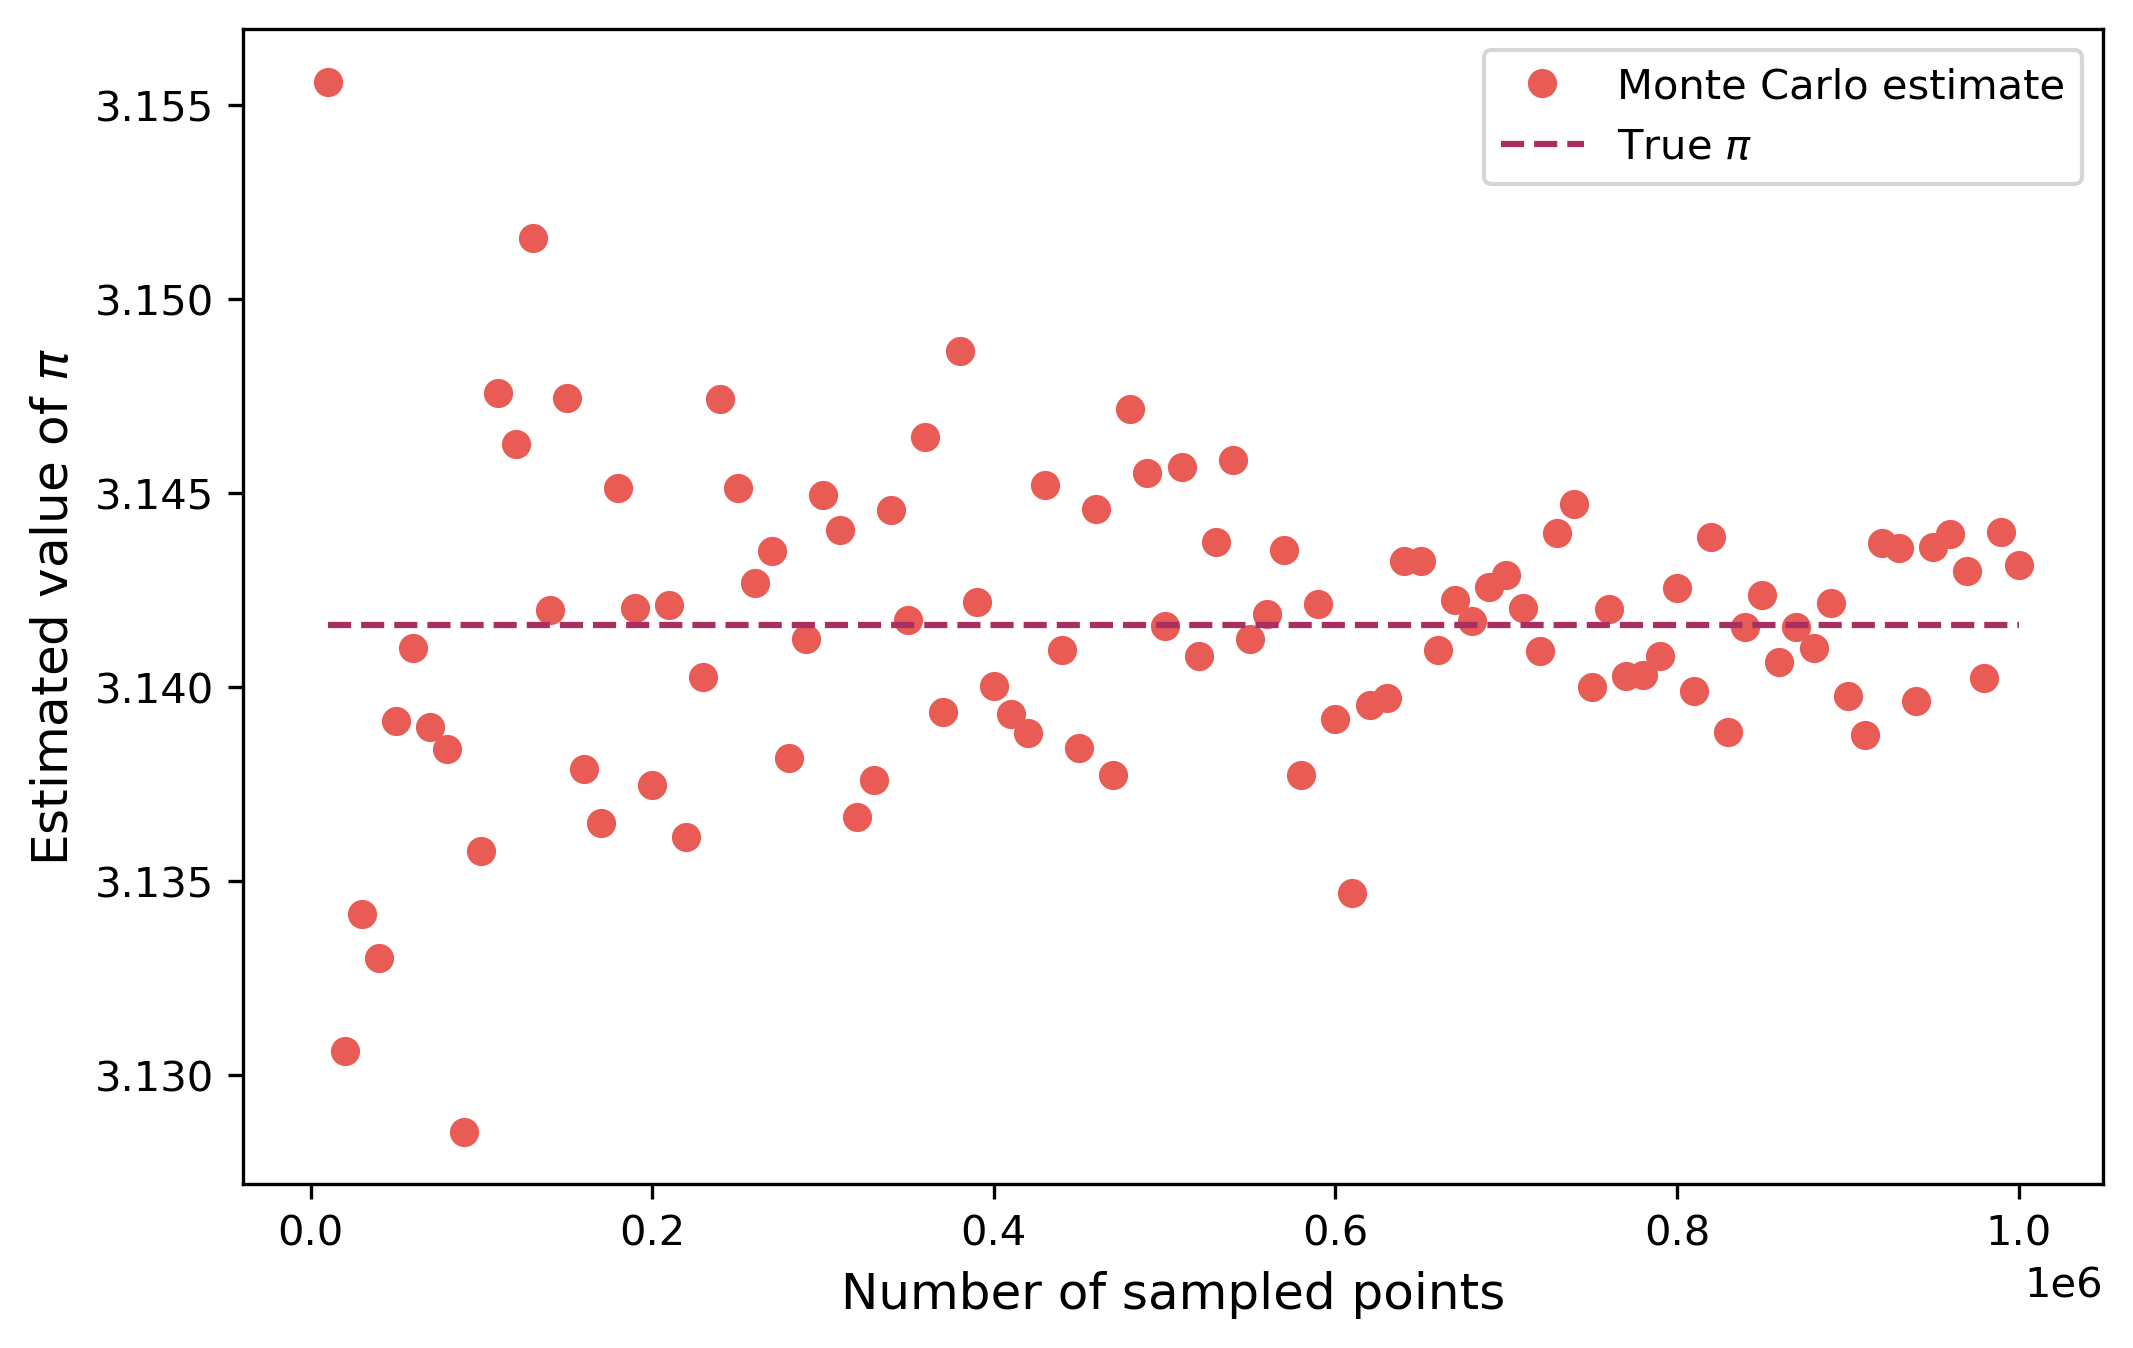

In [19]:
import matplotlib.pyplot as plt

Ns = []
approximations = []

for N in range (10_000, 1_000_001, 10_000): #change to smaller values because it is lowkey long
    approximation = estimate_pi(N)
    Ns.append(N)
    approximations.append(approximation)

plt.figure(figsize=(8, 5), dpi=300) #to have a nice quality

plt.plot(Ns, approximations, linestyle="", marker = "o", color="#E95B55", label="Monte Carlo estimate") # coral, because the default colors are ugly
plt.plot(Ns, [np.pi]*len(Ns), linestyle="--", color="#A92F62",label=r"True $\pi$") # dark magenta

plt.xlabel("Number of sampled points", fontsize=12)
plt.ylabel(r"Estimated value of $\pi$", fontsize=12)
plt.legend()
plt.show()

#### Pushing $N$ further

The plot above covers $N$ from $10^4$ to $10^6$, and to go wider we ran into two limits of the
function as written. It holds every point in memory at once, so memory grows with $N$; and
`np.logspace`, the natural way to space sample sizes across decades, returns **floats**, which NumPy
refuses as an array size.

So we redefine `estimate_pi` with those two fixes — the same progressive-refinement pattern Part A
uses for `molecular_mass`. The algorithm is unchanged: throw points, count the ones inside, multiply
by four. Points are now generated in batches and only counted, never stored, so peak memory is set by
`batch_size` instead of by $N$.

In [20]:
def estimate_pi(N, rng=None, batch_size=1_000_000):
    """Estimate pi by throwing N random points at the square [-1, 1] x [-1, 1].

    Same method as above, with three changes that let N go higher: points are generated
    in batches and only counted, N may be given as a float such as 1e5, and the generator
    can be passed in so a run is reproducible.
    """
    N = int(N)                                  # np.logspace returns floats, not ints
    if N <= 0:
        raise ValueError("N must be a positive integer.")
    if rng is None:
        rng = np.random.default_rng()

    inside_total = 0
    remaining = N
    while remaining > 0:
        n = min(batch_size, remaining)          # the last batch may be smaller
        x = rng.uniform(-1, 1, n)
        y = rng.uniform(-1, 1, n)
        inside_total += np.count_nonzero(x**2 + y**2 <= 1)
        remaining -= n
    return 4 * inside_total / N


print(f"{'N':>12} {'estimate':>12} {'error':>12}")
for N in [1e3, 1e5, 1e7]:
    estimate = estimate_pi(N, rng)
    print(f"{int(N):>12,} {estimate:>12.6f} {abs(estimate - np.pi):>12.6f}")

print(f"\nestimate_pi(1e5) now accepts a float size: "
      f"{estimate_pi(1e5, np.random.default_rng(SEED)):.6f}")
try:
    estimate_pi(0)
except ValueError as error:
    print(f"estimate_pi(0) raises ValueError: {error}")

           N     estimate        error
       1,000     3.140000     0.001593
     100,000     3.136640     0.004953
  10,000,000     3.142008     0.000415

estimate_pi(1e5) now accepts a float size: 3.135640
estimate_pi(0) raises ValueError: N must be a positive integer.


#### The same plot on a logarithmic axis

With that in hand we can redraw the convergence plot over six decades instead of two. Two choices
differ from the figure above.

The $x$ axis is **logarithmic** and starts at $N = 10$. On a linear axis everything below $10^6$ is
squashed against the left edge — and that squashed region is exactly where the estimate swings
wildly, which is the behaviour worth seeing.

We still plot **one independent run per sample size** rather than an average, because the scatter is
itself the result.

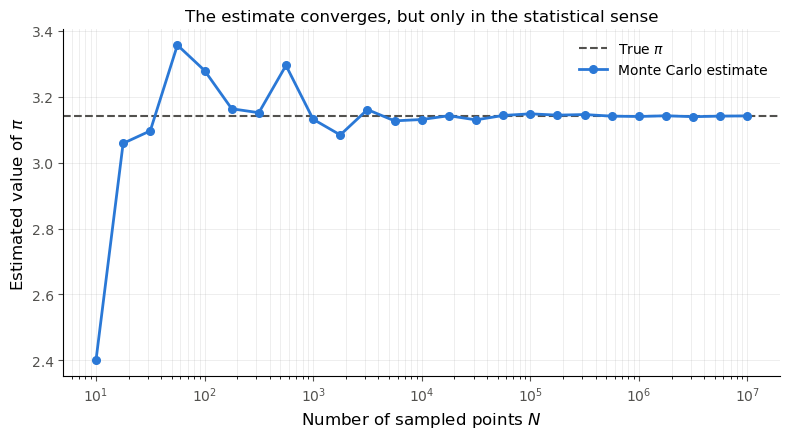

worst run: N = 10 gave 2.4000, off by 0.7416
the last five runs:
   N =  1,000,000   estimate = 3.14040   error = 0.00119
   N =  1,778,279   estimate = 3.14257   error = 0.00097
   N =  3,162,277   estimate = 3.13978   error = 0.00181
   N =  5,623,413   estimate = 3.14155   error = 0.00004
   N = 10,000,000   estimate = 3.14218   error = 0.00058


In [21]:
Ns = np.logspace(1, 7, 25)            # floats, handled by the int(N) cast
estimates = np.array([estimate_pi(N, rng) for N in Ns])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(np.pi, color=INK, linestyle="--", linewidth=1.5, label=r"True $\pi$")
ax.semilogx(Ns, estimates, marker="o", markersize=5.5, linewidth=2,
            color=SERIES, label="Monte Carlo estimate")

ax.set_xlabel("Number of sampled points $N$", fontsize=12)
ax.set_ylabel(r"Estimated value of $\pi$", fontsize=12)
ax.set_title("The estimate converges, but only in the statistical sense")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.25, linewidth=0.6)
ax.tick_params(colors=INK)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

worst = int(np.argmax(np.abs(estimates - np.pi)))
print(f"worst run: N = {int(Ns[worst]):,} gave {estimates[worst]:.4f}, "
      f"off by {abs(estimates[worst] - np.pi):.4f}")
print("the last five runs:")
for N, estimate in zip(Ns[-5:], estimates[-5:]):
    print(f"   N = {int(N):>10,}   estimate = {estimate:.5f}   error = {abs(estimate - np.pi):.5f}")

The points form a funnel: wild on the left, pinching towards the dashed line on the right. What
improves with $N$ is the **width of the funnel**, not a steady march of one number towards π — even at
$N = 10$ the estimator is not biased high or low, only imprecise.

The last five runs are the interesting part. Over that stretch $N$ grows tenfold, which should shrink
the error by about a factor of three, but the sequence just bounces. That looks like the method
hitting a floor, or like a bug. It is neither.

#### How fast does it converge?

A single run per $N$ is one draw from a distribution, so to see the trend we average the noise out: at
each $N$ we run the estimator 30 times and record the **mean absolute error**.

There is a prediction to test against. The number of points inside the circle is binomial with
$p = \pi/4$, so $\hat{\pi} = 4\,(\text{inside}/N)$ has standard deviation

$$
\sigma(N) = 4\sqrt{\frac{p(1-p)}{N}} \approx \frac{1.64}{\sqrt{N}},
$$

and for a roughly normal quantity the mean absolute deviation is $\sigma\sqrt{2/\pi}$. On log-log axes
that is a straight line of slope $-\tfrac{1}{2}$ with **no free parameters to fit**.

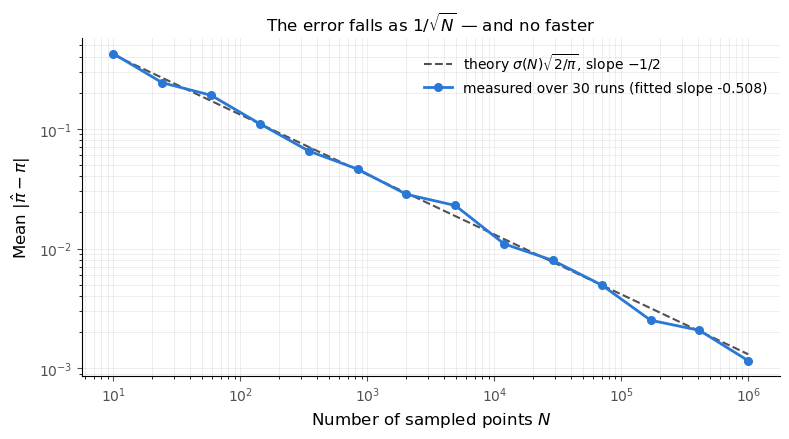

fitted slope      = -0.5082   (theory -0.5)
measured / theory = 0.988 on average

what accuracy costs, read off the fit:
   error below 5e-03  (~2 correct decimals)  needs N of about 63,162
   error below 5e-04  (~3 correct decimals)  needs N of about 5,866,499
   error below 5e-05  (~4 correct decimals)  needs N of about 544,879,891


In [22]:
TRIALS = 30
Ns_law = np.logspace(1, 6, 14)
mean_abs_error = np.array([
    np.mean([abs(estimate_pi(N, rng) - np.pi) for _ in range(TRIALS)])
    for N in Ns_law
])

p = np.pi / 4
theory = 4 * np.sqrt(p * (1 - p) / Ns_law) * np.sqrt(2 / np.pi)
slope, intercept = np.polyfit(np.log10(Ns_law), np.log10(mean_abs_error), 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(Ns_law, theory, color=INK, linestyle="--", linewidth=1.5,
          label=r"theory $\sigma(N)\sqrt{2/\pi}$, slope $-1/2$")
ax.loglog(Ns_law, mean_abs_error, marker="o", markersize=5.5, linewidth=2,
          color=SERIES, label=f"measured over {TRIALS} runs (fitted slope {slope:.3f})")

ax.set_xlabel("Number of sampled points $N$", fontsize=12)
ax.set_ylabel(r"Mean $|\hat{\pi} - \pi|$", fontsize=12)
ax.set_title(r"The error falls as $1/\sqrt{N}$ — and no faster")
ax.legend(frameon=False)
ax.grid(True, which="both", alpha=0.25, linewidth=0.6)
ax.tick_params(colors=INK)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

print(f"fitted slope      = {slope:.4f}   (theory -0.5)")
print(f"measured / theory = {np.mean(mean_abs_error / theory):.3f} on average")
print("\nwhat accuracy costs, read off the fit:")
for decimals, target in [(2, 5e-3), (3, 5e-4), (4, 5e-5)]:
    N_needed = 10 ** ((np.log10(target) - intercept) / slope)
    print(f"   error below {target:.0e}  (~{decimals} correct decimals)  needs N of about {N_needed:,.0f}")

**The measurements land on the prediction**, which settles the puzzle from the previous figure.
Because the error falls as $N^{-1/2}$, a tenfold increase in $N$ buys only a factor
$\sqrt{10} \approx 3.2$ — and the run-to-run scatter at fixed $N$ is of that same size, so a single
sample per $N$ cannot resolve the improvement at all. Nothing was broken.

Turned around, the same law is a price list: **one more correct decimal costs a hundredfold increase
in $N$**. That is the real argument against the 100-million-point version we started with. It was not
just slow; it would have spent minutes of computation to buy roughly half a decimal place.

What we carry into Part 2: a Monte Carlo estimate without a sense of its $\sigma$ is not yet a result.

## Part 2 - Chemistry inspired Monte Carlo


It isn't obvious where to start, so let's build on what we already have and reuse our position randomizer from before


In [23]:
random_collisions = np.random.uniform(-1, 1, size=(1_000_000, 2))
random_energies = np.random.uniform(0,100,size=1_000_000) #same principle here
#we also have to make sure that arrays have the same number of collisions
threshold_energy = 50
threshold = random_energies >= threshold_energy #choosing the energies above the threshold
above_threshold = random_collisions[threshold] #not neccessary per say, but added in case we want to have them 

print(len(above_threshold))
print(len(above_threshold)/len(random_collisions))


499986
0.499986


We assume that a collision leads to a reaction when

$$
E \geq E_{\text{threshold}}.
$$

We can estimate the reaction probability as

$$
P(\text{reaction})
\approx
\frac{N_{\text{above threshold}}}{M}.
$$

Now let's wrap it up into a nice function


In [24]:
def simulate_collisions(number_of_collisions, energy_min, energy_max, threshold_energy):
    random_collisions = np.random.uniform(-1, 1, size=(number_of_collisions, 2))
    random_energies = np.random.uniform(energy_min,energy_max,size=number_of_collisions)
    energy_above = random_energies >= threshold_energy
    above_threshold = random_collisions[energy_above]

    above = len(above_threshold)
    probability = len(above_threshold)/len(random_collisions)
    return above, probability

simulate_collisions(1_000_000, 0, 1000, 750)


(249454, 0.249454)

#### What the uniform model can and cannot tell us

`simulate_collisions` is a correct implementation, and running it at a few thresholds shows something
about the model rather than about the code.

In [25]:
print(f"{'range':>12}{'threshold':>11}{'reactive':>11}{'P':>9}{'exact':>9}")
for energy_max, threshold in [(100, 50), (100, 75), (1000, 750), (1000, 900)]:
    count, probability = simulate_collisions(1_000_000, 0, energy_max, threshold)
    exact = (energy_max - threshold) / energy_max
    print(f"{'0-' + str(energy_max):>12}{threshold:>11}{count:>11,}{probability:>9.4f}{exact:>9.4f}")

       range  threshold   reactive        P    exact
       0-100         50    500,226   0.5002   0.5000
       0-100         75    250,027   0.2500   0.2500
      0-1000        750    249,756   0.2498   0.2500


      0-1000        900     99,350   0.0993   0.1000


The last two columns agree every time, and they have to: if energies are spread evenly, the fraction
above a threshold is just the fraction of the range that lies above it. The simulation recovers a
number we could have written down without simulating anything. It is a correct implementation of a
model that has nothing to say — and, having no temperature in it, nothing to say about chemistry
either.

Real collision energies are not spread evenly. At a given temperature they follow a **Boltzmann
distribution**, where low energies are common and high ones are exponentially rare. For the energy in
a single degree of freedom that is an exponential distribution with mean $RT$:

$$
f(E) = \frac{1}{RT}\,e^{-E/RT}.
$$

This model has a temperature in it, which is what makes it worth simulating. It also has an exact
answer to check against — the fraction of collisions above $E_a$ is

$$
P(E \geq E_a) = \int_{E_a}^{\infty} \frac{1}{RT}e^{-E/RT}\,dE = e^{-E_a/RT},
$$

which is the **Arrhenius exponential factor**. So this counting experiment should reproduce the
temperature dependence of a reaction rate.

In [26]:
R = 8.314462618e-3              # gas constant in kJ / (mol K)
ACTIVATION_ENERGY = 25.0        # kJ/mol
M = 1_000_000


def sample_collision_energies(number_of_collisions, temperature, distribution="boltzmann",
                              energy_max=50.0, rng=None):
    """Draw collision energies in kJ/mol.

    "boltzmann" gives exponentially distributed energies with mean R*T; "uniform" keeps
    the model above, on the same scale, for comparison.
    """
    if rng is None:
        rng = np.random.default_rng()
    if distribution == "boltzmann":
        return rng.exponential(R * temperature, size=number_of_collisions)
    if distribution == "uniform":
        return rng.uniform(0, energy_max, size=number_of_collisions)
    raise ValueError(f"unknown distribution: {distribution!r}")


def reaction_probability(energies, threshold_energy):
    """Fraction of collisions clearing the barrier, with its standard error."""
    reactive = int(np.count_nonzero(energies >= threshold_energy))
    probability = reactive / energies.size
    standard_error = np.sqrt(probability * (1 - probability) / energies.size)
    return probability, standard_error


TEMPERATURE = 500.0
uniform_energies = sample_collision_energies(M, TEMPERATURE, "uniform", rng=rng)
boltzmann_energies = sample_collision_energies(M, TEMPERATURE, "boltzmann", rng=rng)

probability, standard_error = reaction_probability(boltzmann_energies, ACTIVATION_ENERGY)
analytic = np.exp(-ACTIVATION_ENERGY / (R * TEMPERATURE))

print(f"T = {TEMPERATURE:.0f} K, mean collision energy RT = {R * TEMPERATURE:.2f} kJ/mol")
print(f"simulated P(reaction) = {probability:.5f} +/- {standard_error:.5f}")
print(f"analytic  exp(-Ea/RT) = {analytic:.5f}")
print(f"difference = {abs(probability - analytic) / standard_error:.1f} standard errors")

T = 500 K, mean collision energy RT = 4.16 kJ/mol
simulated P(reaction) = 0.00242 +/- 0.00005
analytic  exp(-Ea/RT) = 0.00245
difference = 0.6 standard errors


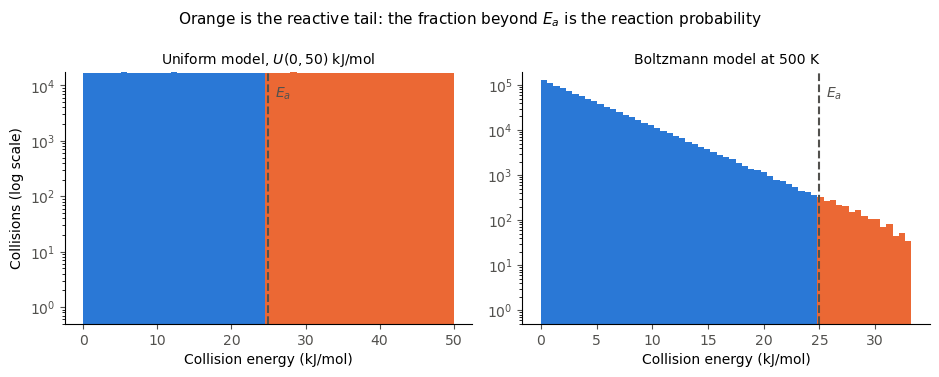

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

for ax, (energies, title, upper) in zip(axes, [
    (uniform_energies, "Uniform model, $U(0, 50)$ kJ/mol", 50.0),
    (boltzmann_energies, f"Boltzmann model at {TEMPERATURE:.0f} K", 8 * R * TEMPERATURE),
]):
    counts, edges = np.histogram(energies, bins=np.linspace(0, upper, 60))
    centres = (edges[:-1] + edges[1:]) / 2
    colours = np.where(centres >= ACTIVATION_ENERGY, SECOND, SERIES)
    ax.bar(centres, counts, width=edges[1] - edges[0], color=colours, linewidth=0)
    ax.axvline(ACTIVATION_ENERGY, color=INK, linestyle="--", linewidth=1.5)

    # A log y axis is what makes the point: on the right the reactive tail is thousands of
    # times rarer than a typical collision and would be invisible on a linear scale.
    ax.set_yscale("log")
    ax.set_ylim(bottom=0.5)
    ax.annotate(r"$E_a$", xy=(ACTIVATION_ENERGY, 0.90), xycoords=ax.get_xaxis_transform(),
                xytext=(5, 0), textcoords="offset points", color=INK)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Collision energy (kJ/mol)")
    ax.tick_params(colors=INK)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Collisions (log scale)")
fig.suptitle("Orange is the reactive tail: the fraction beyond $E_a$ is the reaction probability",
             fontsize=11)
fig.tight_layout()
plt.show()

The two panels are the whole argument. In the uniform model the barrier cuts the distribution in half,
which is why the answer was fixed by construction. In the Boltzmann model the barrier sits far out in
an exponential tail, so the reactive fraction is small — and, crucially, **exquisitely sensitive to
temperature**, because raising $T$ stretches that tail.

That sensitivity is testable. If $P = e^{-E_a/RT}$ is really what the counting produces, then plotting
$\ln P$ against $1/T$ must give a straight line of slope $-E_a/R$. So we can run the simulation at
several temperatures and **recover the activation energy we put in**, without ever using the formula.

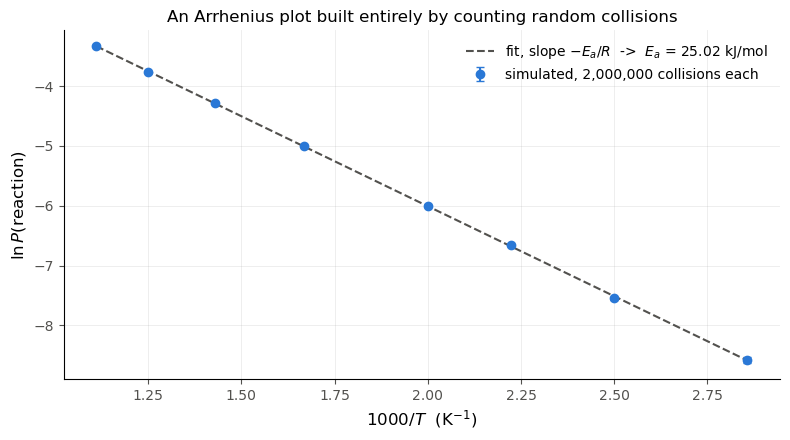

  T (K)  reactive   P simulated   P analytic  difference
    350       377      1.89e-04     1.86e-04        1.5%
    400     1,053      5.26e-04     5.44e-04       -3.2%
    450     2,586      1.29e-03     1.25e-03        3.1%
    500     4,925      2.46e-03     2.45e-03        0.7%
    600    13,555      6.78e-03     6.66e-03        1.7%
    700    27,593      1.38e-02     1.36e-02        1.2%
    800    46,609      2.33e-02     2.33e-02       -0.1%
    900    71,220      3.56e-02     3.54e-02        0.6%

activation energy put in:    25.00 kJ/mol
activation energy recovered: 25.02 kJ/mol (0.09% off)


In [28]:
temperatures = np.array([350.0, 400.0, 450.0, 500.0, 600.0, 700.0, 800.0, 900.0])
M_sweep = 2_000_000

probabilities, standard_errors = [], []
for temperature in temperatures:
    energies = sample_collision_energies(M_sweep, temperature, "boltzmann", rng=rng)
    probability, standard_error = reaction_probability(energies, ACTIVATION_ENERGY)
    probabilities.append(probability)
    standard_errors.append(standard_error)
probabilities = np.array(probabilities)
standard_errors = np.array(standard_errors)

# ln P = -(Ea/R) * (1/T), so the slope of the fit hands back the activation energy.
slope, intercept = np.polyfit(1 / temperatures, np.log(probabilities), 1)
recovered_Ea = -slope * R

fig, ax = plt.subplots(figsize=(8, 4.5))
grid = np.linspace(1 / temperatures.max(), 1 / temperatures.min(), 50)
ax.plot(1000 * grid, slope * grid + intercept, color=INK, linestyle="--", linewidth=1.5,
        label=f"fit, slope $-E_a/R$  ->  $E_a$ = {recovered_Ea:.2f} kJ/mol")
ax.errorbar(1000 / temperatures, np.log(probabilities),
            yerr=standard_errors / probabilities, fmt="o", markersize=6,
            color=SERIES, ecolor=SERIES, capsize=3, linewidth=0, elinewidth=1.5,
            label=f"simulated, {M_sweep:,} collisions each")

ax.set_xlabel("$1000/T$  (K$^{-1}$)", fontsize=12)
ax.set_ylabel(r"$\ln P(\mathrm{reaction})$", fontsize=12)
ax.set_title("An Arrhenius plot built entirely by counting random collisions")
ax.legend(frameon=False)
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.tick_params(colors=INK)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()

print(f"{'T (K)':>7}{'reactive':>10}{'P simulated':>14}{'P analytic':>13}{'difference':>12}")
for temperature, probability in zip(temperatures, probabilities):
    analytic = np.exp(-ACTIVATION_ENERGY / (R * temperature))
    print(f"{temperature:>7.0f}{probability * M_sweep:>10,.0f}{probability:>14.2e}"
          f"{analytic:>13.2e}{(probability - analytic) / analytic * 100:>11.1f}%")

print(f"\nactivation energy put in:    {ACTIVATION_ENERGY:.2f} kJ/mol")
print(f"activation energy recovered: {recovered_Ea:.2f} kJ/mol "
      f"({abs(recovered_Ea - ACTIVATION_ENERGY) / ACTIVATION_ENERGY * 100:.2f}% off)")

#### What we learned

The simulation never uses $e^{-E_a/RT}$ anywhere. It draws random energies, compares each one to a
number, and counts — and out of that counting comes a straight Arrhenius line whose slope returns the
activation energy we started from, to within a fraction of a percent. A macroscopic rate law falls out
of a microscopic model with nothing in between but arithmetic on random numbers.

Two lessons carry over from Part 1.

**The error bars matter, and they come from the same $1/\sqrt{N}$ law.** At the lowest temperature
only a few hundred of two million collisions react, so that point carries the largest relative
uncertainty — and the fit leans on it hardest, since it sits at the far end of the $1/T$ axis.

**Choosing the distribution is the modelling; the code is not.** The uniform and Boltzmann runs differ
by one argument and share all their machinery. But the first returns a number fixed by construction
and the second reproduces a law of physical chemistry. The interesting work was deciding what to
sample from.

### Part C in one line

Monte Carlo turns a question into a counting experiment. The answer is a random variable whose typical
error falls as $1/\sqrt{N}$, so accuracy starts cheap and quickly becomes expensive — and once that is
understood, the same few lines of counting give π from a square or an activation energy from a box of
colliding molecules.